# **라이브러리 불러오기**

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import datetime

# **데이터 불러오기**

In [3]:
df = pd.read_csv("./data/train2.csv")

In [4]:
df.head()

,년월일,최대순간풍속(m/s),최저기온(℃),최고기온(℃),일강수량(mm),최저습도(%),최고습도(%),최저기압(hPa),최고기압(hPa),PM10_일별평균,PM2.5_일별평균
0,2024-01-01,4.5,-0.3,7.3,0.0,65,100,"1,024.80","1,029.40",24.56,19.44
1,2024-01-02,5.3,2.2,4.3,0.0,59,86,"1,020.30","1,024.90",39.40,28.68
2,2024-01-03,7.6,-1.1,4.0,0.6,72,90,"1,017","1,022.30",41.88,29.48
3,2024-01-04,6.1,-3.3,4.7,0.0,64,88,"1,019.30","1,024.40",51.64,36.04
4,2024-01-05,10.3,1.4,9.1,0.0,59,89,"1,018.30","1,020.90",80.44,55.76


# **데이터 전처리**

In [6]:
df["최저기압(hPa)"] = df["최저기압(hPa)"].str.replace(",", "").astype(float)
df["최고기압(hPa)"] = df["최고기압(hPa)"].str.replace(",", "").astype(float)

In [7]:
df["년월일"] = pd.to_datetime(df["년월일"])

In [8]:
df["month"] = df["년월일"].dt.month
df["day"] = df["년월일"].dt.day
df["weekday"] = df["년월일"].dt.weekday
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

In [9]:
df.head()

,년월일,최대순간풍속(m/s),최저기온(℃),최고기온(℃),일강수량(mm),최저습도(%),최고습도(%),최저기압(hPa),최고기압(hPa),PM10_일별평균,PM2.5_일별평균,month,day,weekday,is_weekend
0,2024-01-01,4.5,-0.3,7.3,0.0,65,100,1024.8,1029.4,24.56,19.44,1,1,0,0
1,2024-01-02,5.3,2.2,4.3,0.0,59,86,1020.3,1024.9,39.40,28.68,1,2,1,0
2,2024-01-03,7.6,-1.1,4.0,0.6,72,90,1017.0,1022.3,41.88,29.48,1,3,2,0
3,2024-01-04,6.1,-3.3,4.7,0.0,64,88,1019.3,1024.4,51.64,36.04,1,4,3,0
4,2024-01-05,10.3,1.4,9.1,0.0,59,89,1018.3,1020.9,80.44,55.76,1,5,4,0


# **피처 및 타겟 설정하기**

In [11]:
features = ["최대순간풍속(m/s)", '최저기온(℃)', '최고기온(℃)', "일강수량(mm)", "최저습도(%)", "최고습도(%)", "최저기압(hPa)", "최고기압(hPa)", "month", "day", "is_weekend"]
target_pm10 = "PM10_일별평균"
target_pm25 = "PM2.5_일별평균"

# **데이터 분리**

In [29]:
x = df[features]
y_pm10 = df[target_pm10]
y_pm25 = df[target_pm25]

In [31]:
x_train, x_test, y_train_pm10, y_test_pm10 = train_test_split(x, y_pm10, test_size = 0.2, random_state = 22)
x_train, x_test, y_train_pm25, y_test_pm25 = train_test_split(x, y_pm25, test_size = 0.2, random_state = 22)

In [33]:
x_train.shape, y_train_pm10.shape

((292, 11), (292,))

In [35]:
x_test.shape, y_test_pm10.shape

((73, 11), (73,))

# **모델 학습(XGBoost)**

In [176]:
model_pm10 = XGBRegressor(n_estimators = 100, random_state = 22)

In [40]:
model_pm10.fit(x_train, y_train_pm10)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
model_pm25 = XGBRegressor(n_estimators = 100, random_state = 22)

In [44]:
model_pm25.fit(x_train, y_train_pm25)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [48]:
# 성능 평가
print("PM10 MAE:", mean_absolute_error(y_test_pm10, model_pm10.predict(x_test)))
print("PM2.5 MAE:", mean_absolute_error(y_test_pm25, model_pm25.predict(x_test)))

PM10 MAE: 9.751381488770939
PM2.5 MAE: 5.671432452921241


In [45]:
# 하이퍼파라미터 튜닝
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

grid_pm10 = GridSearchCV(XGBRegressor(), param_grid, cv=3, scoring='neg_mean_absolute_error')
grid_pm10.fit(x_train, y_train_pm10)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_error')

In [46]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

grid_pm25 = GridSearchCV(XGBRegressor(), param_grid, cv=3, scoring='neg_mean_absolute_error')
grid_pm25.fit(x_train, y_train_pm25)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_error')

In [53]:
print(grid_pm10.best_params_)

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}


In [55]:
print(grid_pm25.best_params_)

{'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}


In [63]:
# 튜닝에 따른 모델 평가 다시하기
model_pm10 = XGBRegressor(n_estimators = 300, learning_rate = 0.01, max_depth = 5, random_state = 22)

In [65]:
model_pm10.fit(x_train, y_train_pm10)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
model_pm25 = XGBRegressor(n_estimators = 300, learning_rate = 0.2, max_depth = 7, random_state = 22)

In [69]:
model_pm25.fit(x_train, y_train_pm25)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [71]:
# 성능 평가
print("PM10 MAE:", mean_absolute_error(y_test_pm10, model_pm10.predict(x_test)))
print("PM2.5 MAE:", mean_absolute_error(y_test_pm25, model_pm25.predict(x_test)))

PM10 MAE: 9.637649969672788
PM2.5 MAE: 5.650566980545712


# **5월 데이터 예측하기**

In [73]:
future_dates = pd.date_range(start = "2025-05-01", end = "2025-05-31")

In [75]:
future_df = pd.DataFrame({
    "년월일" : future_dates,
    "month" : future_dates.month,
    "day" : future_dates.day,
    "weekday" : future_dates.weekday,
    "is_weekend" : future_dates.weekday >= 5
})

In [77]:
future_df.head()

,년월일,month,day,weekday,is_weekend
0,2025-05-01,5,1,3,False
1,2025-05-02,5,2,4,False
2,2025-05-03,5,3,5,True
3,2025-05-04,5,4,6,True
4,2025-05-05,5,5,0,False


In [79]:
mean_values = df[[
    '최대순간풍속(m/s)', '최저기온(℃)', '최고기온(℃)', '일강수량(mm)', '최저습도(%)', '최고습도(%)', '최저기압(hPa)', '최고기압(hPa)'
]].mean()

In [81]:
for col in mean_values.index:
    future_df[col] = mean_values[col]

## 예측 실행

In [84]:
x_future = future_df[features]
pred_pm10 = model_pm10.predict(x_future)
pred_pm25 = model_pm25.predict(x_future)

In [86]:
future_df["PM10_예측"] = pred_pm10
future_df["PM2.5_예측"] = pred_pm25

In [88]:
print(future_df[["년월일", "PM10_예측", "PM2.5_예측"]])

          년월일    PM10_예측   PM2.5_예측
0  2025-05-01  34.398262  14.496421
1  2025-05-02  34.398262  14.332713
2  2025-05-03  31.866804  13.473941
3  2025-05-04  28.988522  12.813908
4  2025-05-05  29.937222  13.590344
5  2025-05-06  29.738153  13.574452
6  2025-05-07  29.738153  13.580176
7  2025-05-08  29.738153  13.573704
8  2025-05-09  29.738153  12.909291
9  2025-05-10  27.781019  12.755849
10 2025-05-11  27.781019  12.751053
11 2025-05-12  30.113407  13.602460
12 2025-05-13  30.113407  13.602460
13 2025-05-14  30.113407  13.602460
14 2025-05-15  29.694899  13.510563
15 2025-05-16  29.694899  13.519691
16 2025-05-17  27.362511  12.787079
17 2025-05-18  27.362511  12.785978
18 2025-05-19  29.754894  13.611838
19 2025-05-20  29.754894  13.618680
20 2025-05-21  29.754894  13.129738
21 2025-05-22  29.358416  13.132866
22 2025-05-23  26.685349  13.103480
23 2025-05-24  24.352961  12.315101
24 2025-05-25  24.352961  12.315101
25 2025-05-26  26.809242  13.084687
26 2025-05-27  26.809242  13

# **시각화**

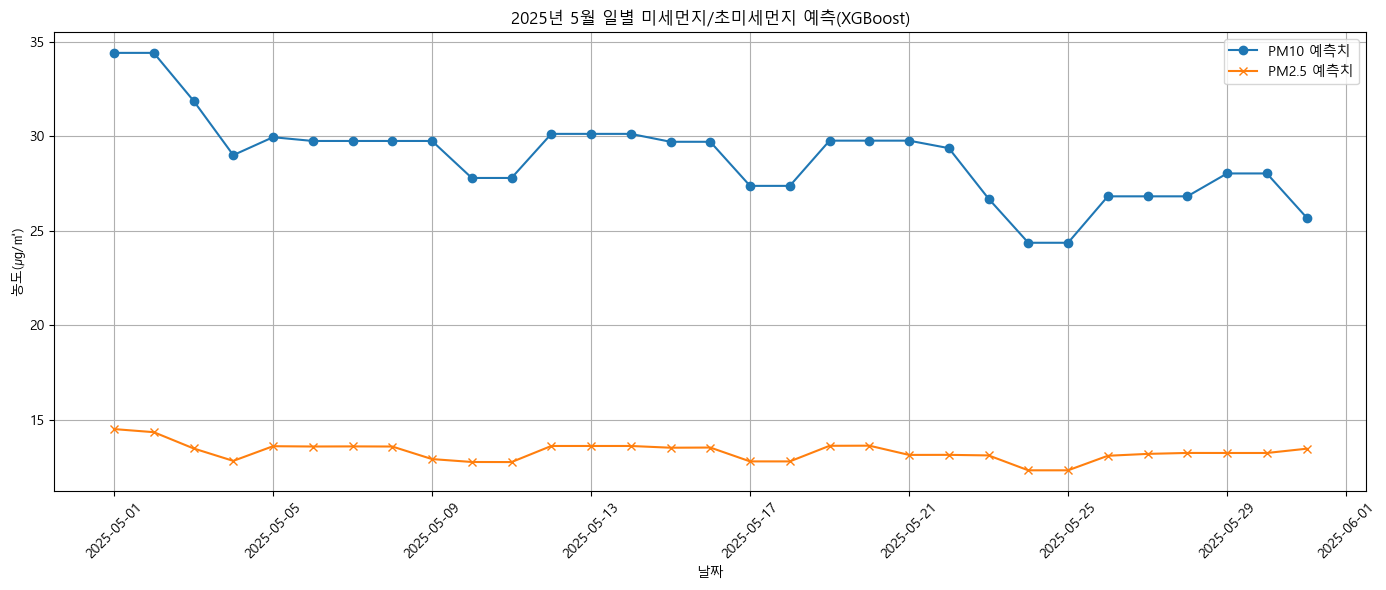

In [93]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (14, 6))
plt.plot(future_df["년월일"], future_df["PM10_예측"], marker = "o", label = "PM10 예측치")
plt.plot(future_df["년월일"], future_df["PM2.5_예측"], marker = "x", label = "PM2.5 예측치")
plt.title("2025년 5월 일별 미세먼지/초미세먼지 예측(XGBoost)")
plt.xlabel("날짜")
plt.ylabel("농도(㎍/㎥)")
plt.legend()
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# **모델 학습(랜덤포레스트)**

In [97]:
rf_pm10 = RandomForestRegressor(n_estimators = 100, random_state = 22)

In [99]:
rf_pm10.fit(x_train, y_train_pm10)

RandomForestRegressor(random_state=22)

In [100]:
rf_pm25 = RandomForestRegressor(n_estimators = 100, random_state = 22)

In [103]:
rf_pm25.fit(x_train, y_train_pm25)

RandomForestRegressor(random_state=22)

In [104]:
# 성능 평가
print("RF PM10 MAE:", mean_absolute_error(y_test_pm10, rf_pm10.predict(x_test)))
print("RF PM2.5 MAE:", mean_absolute_error(y_test_pm25, rf_pm25.predict(x_test)))

RF PM10 MAE: 9.624675242302512
RF PM2.5 MAE: 5.772305837986305


## 예측 실행

In [108]:
x_future = future_df[features]
rf_pred_pm10 = rf_pm10.predict(x_future)
rf_pred_pm25 = rf_pm25.predict(x_future)

In [110]:
future_df["PM10_예측"] = rf_pred_pm10
future_df["PM2.5_예측"] = rf_pred_pm25

In [112]:
print(future_df[["년월일", "PM10_예측", "PM2.5_예측"]])

          년월일    PM10_예측   PM2.5_예측
0  2025-05-01  30.076801  15.960381
1  2025-05-02  30.076801  15.960381
2  2025-05-03  29.207028  15.303981
3  2025-05-04  29.403255  14.920381
4  2025-05-05  29.883379  15.014381
5  2025-05-06  29.760179  14.934518
6  2025-05-07  29.806579  15.052118
7  2025-05-08  29.649379  15.113718
8  2025-05-09  29.526579  15.062918
9  2025-05-10  29.121832  15.390381
10 2025-05-11  29.253432  15.491581
11 2025-05-12  29.404579  15.133718
12 2025-05-13  29.004179  15.170118
13 2025-05-14  28.682250  15.139318
14 2025-05-15  28.758855  15.237318
15 2025-05-16  29.031655  15.237318
16 2025-05-17  28.182509  15.271981
17 2025-05-18  27.958282  15.252781
18 2025-05-19  28.831428  15.467318
19 2025-05-20  28.831428  15.751318
20 2025-05-21  27.673428  15.810118
21 2025-05-22  27.711828  15.676918
22 2025-05-23  27.875028  15.522118
23 2025-05-24  26.931655  15.043581
24 2025-05-25  26.654055  14.690781
25 2025-05-26  27.553028  14.625718
26 2025-05-27  27.607828  14

## 시각화

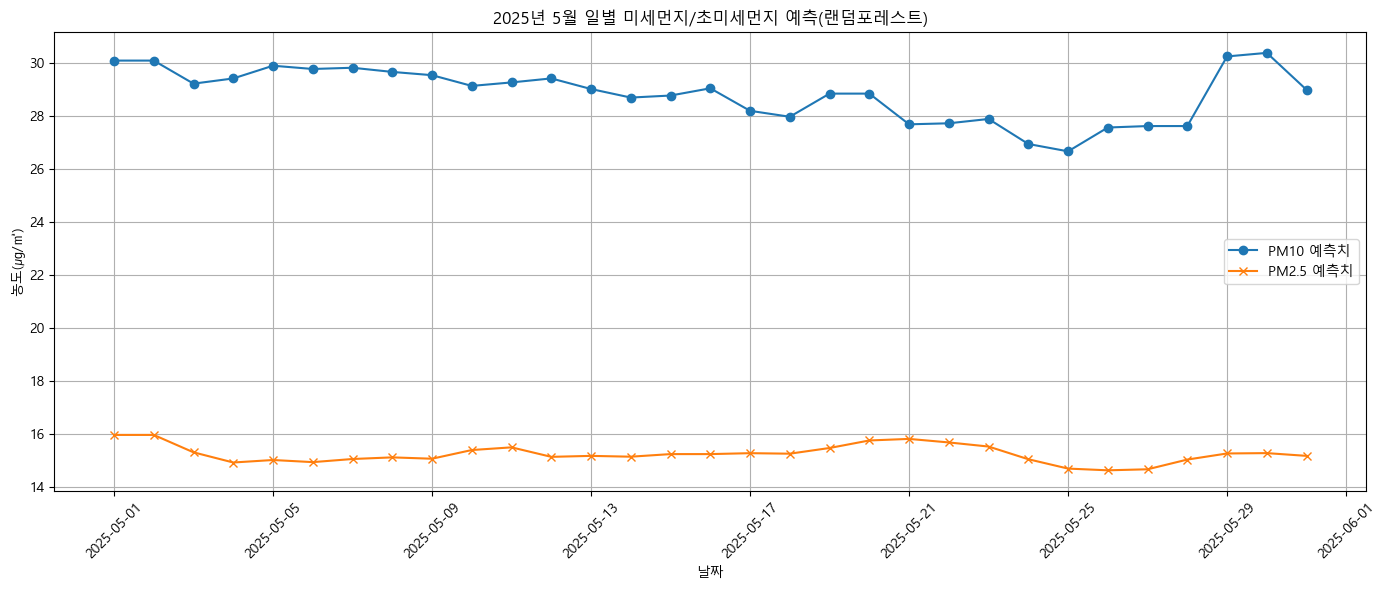

In [115]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (14, 6))
plt.plot(future_df["년월일"], future_df["PM10_예측"], marker = "o", label = "PM10 예측치")
plt.plot(future_df["년월일"], future_df["PM2.5_예측"], marker = "x", label = "PM2.5 예측치")
plt.title("2025년 5월 일별 미세먼지/초미세먼지 예측(랜덤포레스트)")
plt.xlabel("날짜")
plt.ylabel("농도(㎍/㎥)")
plt.legend()
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# **모델 학습(KNN회귀)**

In [118]:
kn_pm10 = KNeighborsRegressor(n_neighbors = 5)

In [120]:
kn_pm10.fit(x_train, y_train_pm10)

KNeighborsRegressor()

In [122]:
kn_pm25 = KNeighborsRegressor(n_neighbors = 5)

In [124]:
kn_pm25.fit(x_train, y_train_pm25)

KNeighborsRegressor()

In [126]:
# 성능 평가
print("KN PM10 MAE:", mean_absolute_error(y_test_pm10, kn_pm10.predict(x_test)))
print("KN PM2.5 MAE:", mean_absolute_error(y_test_pm25, kn_pm25.predict(x_test)))

KN PM10 MAE: 11.681493251349565
KN PM2.5 MAE: 7.046197334971597


## 예측 실행

In [129]:
x_future = future_df[features]
kn_pred_pm10 = kn_pm10.predict(x_future)
kn_pred_pm25 = kn_pm25.predict(x_future)

In [131]:
future_df["PM10_예측"] = kn_pred_pm10
future_df["PM2.5_예측"] = kn_pred_pm25

In [133]:
print(future_df[["년월일", "PM10_예측", "PM2.5_예측"]])

          년월일    PM10_예측   PM2.5_예측
0  2025-05-01  23.232000  12.304000
1  2025-05-02  27.808000  15.528000
2  2025-05-03  27.808000  15.528000
3  2025-05-04  27.808000  15.528000
4  2025-05-05  29.760000  15.016000
5  2025-05-06  29.760000  15.016000
6  2025-05-07  29.760000  15.016000
7  2025-05-08  27.765879  13.698443
8  2025-05-09  27.765879  13.698443
9  2025-05-10  27.765879  13.698443
10 2025-05-11  25.529785  12.877181
11 2025-05-12  26.789879  12.978443
12 2025-05-13  26.789879  12.978443
13 2025-05-14  26.789879  12.978443
14 2025-05-15  26.789879  12.978443
15 2025-05-16  26.789879  12.978443
16 2025-05-17  21.265785  10.901181
17 2025-05-18  34.157879  20.154443
18 2025-05-19  34.157879  20.154443
19 2025-05-20  27.181879  14.546443
20 2025-05-21  27.181879  14.546443
21 2025-05-22  32.144000  18.376000
22 2025-05-23  32.144000  18.376000
23 2025-05-24  31.176000  18.544000
24 2025-05-25  23.632000  12.880000
25 2025-05-26  23.632000  12.880000
26 2025-05-27  23.632000  12

## 시각화

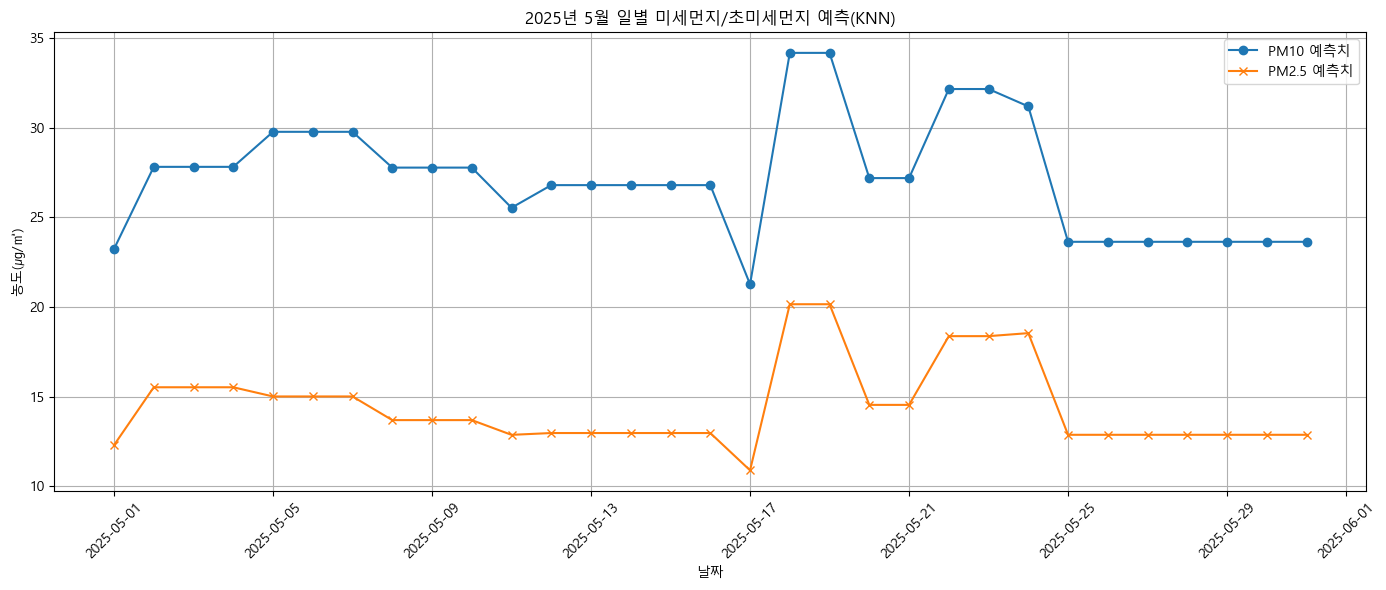

In [136]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (14, 6))
plt.plot(future_df["년월일"], future_df["PM10_예측"], marker = "o", label = "PM10 예측치")
plt.plot(future_df["년월일"], future_df["PM2.5_예측"], marker = "x", label = "PM2.5 예측치")
plt.title("2025년 5월 일별 미세먼지/초미세먼지 예측(KNN)")
plt.xlabel("날짜")
plt.ylabel("농도(㎍/㎥)")
plt.legend()
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()